In [1]:
# Imports
import polars as pl
import numpy as np
import json
import re

In [2]:
norm = pl.read_parquet('./data/normalized_data.parquet')

# Making Polars DataFrame where each row is a pitch
    # (i.e. x_marker_frame, y_marker_frame, z_marker_frame are columns made from x, y, z, frame, and markerID columns of df)
def create_pitch_df(df):
    # Create a Polars DataFrame where each row is a pitch
    pitch_df = df.pivot(
        index = ["userID", "sessionID", "pitchNum", "height", "weight", "pitchType", "pitchSpeed", "p_throws"],
        on = ['markerID', 'frame_norm'],
        values = ['x', 'y', 'z']
    )
    
    # Pattern to match x_{"C7",0} or similar
    pattern = re.compile(r'([xyz])_\{"([^"]+)",(\d+)\}')

    # Change from naming convention of x_{"C7",0} to x_C7_0 
    for col in pitch_df.columns:
        if col.startswith('x_') or col.startswith('y_') or col.startswith('z_'):
            match = pattern.match(col)
            axis, marker, frame = match.groups()
            new_col_name = f"{axis}_{marker}_{frame}"
            pitch_df = pitch_df.rename({col: new_col_name})

    return pitch_df

# Create PCA-ready DataFrame
df = create_pitch_df(norm)
#df = pl.read_parquet('./data/pca_ready_data.parquet')
df.head()

userID,sessionID,pitchNum,height,weight,pitchType,pitchSpeed,p_throws,x_C7_0,x_C7_1,x_C7_2,x_C7_3,x_C7_4,x_C7_5,x_C7_6,x_C7_7,x_C7_8,x_C7_9,x_C7_10,x_C7_11,x_C7_12,x_C7_13,x_C7_14,x_C7_15,x_C7_16,x_C7_17,x_C7_18,x_C7_19,x_C7_20,x_C7_21,x_C7_22,x_C7_23,x_C7_24,x_C7_25,x_C7_26,x_C7_27,x_C7_28,…,z_T10_64,z_T10_65,z_T10_66,z_T10_67,z_T10_68,z_T10_69,z_T10_70,z_T10_71,z_T10_72,z_T10_73,z_T10_74,z_T10_75,z_T10_76,z_T10_77,z_T10_78,z_T10_79,z_T10_80,z_T10_81,z_T10_82,z_T10_83,z_T10_84,z_T10_85,z_T10_86,z_T10_87,z_T10_88,z_T10_89,z_T10_90,z_T10_91,z_T10_92,z_T10_93,z_T10_94,z_T10_95,z_T10_96,z_T10_97,z_T10_98,z_T10_99,z_T10_100
str,str,str,str,str,str,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""000625""","""001612""","""009""","""71""","""201""","""FF""",86.4,"""R""",0.092091,0.092524,0.093068,0.093626,0.094172,0.094493,0.094644,0.094732,0.094838,0.094841,0.094616,0.094131,0.093675,0.09358,0.093919,0.094775,0.095836,0.097039,0.098462,0.099684,0.101247,0.103786,0.106784,0.110946,0.115368,0.119894,0.124681,0.129857,0.135698,…,0.89993,0.891922,0.88466,0.878154,0.872474,0.866843,0.860313,0.854529,0.851542,0.849521,0.851222,0.861358,0.873894,0.887183,0.904839,0.927925,0.948039,0.970808,0.990375,1.009754,1.034968,1.053051,1.067559,1.072852,1.072776,1.074502,1.076596,1.080969,1.086588,1.092972,1.100743,1.108544,1.116572,1.124527,1.131885,1.139176,1.145923
"""001637""","""002918""","""006""","""74""","""221""","""FF""",90.3,"""R""",0.244043,0.244201,0.24429,0.244262,0.244063,0.243837,0.243335,0.242547,0.241697,0.240256,0.238846,0.237029,0.234893,0.232766,0.229991,0.226978,0.223814,0.220502,0.217716,0.215472,0.213625,0.211998,0.210739,0.210163,0.210228,0.210965,0.21225,0.214078,0.215912,…,0.972156,0.966723,0.962101,0.958425,0.955127,0.951888,0.94807,0.942769,0.935377,0.926225,0.915327,0.904128,0.892063,0.880316,0.871585,0.87036,0.874672,0.882954,0.896525,0.915211,0.9387,0.964228,0.991615,1.0157,1.031019,1.040419,1.049024,1.061869,1.069949,1.075056,1.069858,1.062386,1.059769,1.059642,1.059508,1.060225,1.061431
"""000675""","""003065""","""007""","""72""","""182""","""FF""",89.3,"""R""",0.353865,0.353868,0.35355,0.352739,0.351637,0.350446,0.349151,0.348047,0.346825,0.345632,0.343849,0.342022,0.340289,0.338539,0.337421,0.337018,0.33705,0.337403,0.338167,0.339395,0.34077,0.342557,0.344305,0.345882,0.347574,0.348919,0.350496,0.351951,0.353353,…,0.934588,0.928001,0.921683,0.916212,0.911105,0.906402,0.901604,0.895852,0.889658,0.88197,0.874175,0.866325,0.860572,0.858551,0.859158,0.859301,0.865091,0.878183,0.898615,0.916723,0.928497,0.939789,0.950404,0.972294,0.993274,1.009313,1.022276,1.034315,1.042087,1.047767,1.056476,1.06512,1.074376,1.083671,1.092595,1.101377,1.110016
"""001027""","""001782""","""009""","""72""","""215""","""FF""",74.0,"""L""",0.206988,0.205925,0.204283,0.202539,0.200838,0.198381,0.196078,0.193032,0.189547,0.185848,0.181731,0.176943,0.172155,0.167139,0.16161,0.156636,0.151447,0.146794,0.142699,0.138615,0.135063,0.131757,0.128684,0.125907,0.123538,0.121414,0.11975,0.118392,0.117326,…,1.160477,1.146033,1.129894,1.111759,1.09283,1.071638,1.050944,1.03025,1.007888,0.986098,0.963423,0.94209,0.921556,0.900923,0.881012,0.861807,0.844218,0.829576,0.819062,0.814734,0.815732,0.825017,0.84017,0.862787,0.896691,0.919281,0.941075,0.962196,0.981573,0.996552,1.001777,1.003938,1.002201,1.001774,1.002966,1.004185,1.005594
"""001557""","""002760""","""010""","""73""","""182""","""FF""",84.3,"""R""",0.132214,0.132548,0.13291,0.133277,0.133591,0.133845,0.13409,0.134425,0.134875,0.135394,0.136144,0.137115,0.138108,0.139251,0.140276,0.141638,0.143192,0.145353,0.147608,0.150305,0.153282,0.15647,0.160011,0.16352,0.167415,0.17124,0.175269,0.179411,0.183702,…,0.976837,0.96562,0.9545,0.94375,0.932797,0.922418,0.911617,0.900687,0

In [3]:
# Filter rows where any value is null or NaN
df = df.filter(
    ~(
    pl.any_horizontal(
        # Check for missing data AND for floating point NaN
        pl.nth(range(8, len(df.columns))).is_null() | 
        pl.nth(range(8, len(df.columns))).is_nan()
    )
    )
)


In [4]:
# Taking transpose of the PCA-ready DataFrame to get the data in the correct format for PCA
    # (n_pitches, 3 * n_markers * n_frames)

X = df.select(pl.nth(range(8, len(df.columns)))).to_numpy().T

X_mean = np.mean(X, axis=1, keepdims = True)
X_centered = X - X_mean

cov_mat = (X_centered.T @ X_centered) / (X_centered.shape[1] - 1)
print(cov_mat.shape)

eigenvalues, eigenvectors = np.linalg.eigh(cov_mat)

idx = eigenvalues.argsort()[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

for i, eval, evec in zip(range(len(eigenvectors)), eigenvalues, eigenvectors.T):
    if i < 5:
        print(f"Eigenvalue: {np.round(eval,3)}, Eigenvector: {evec[:2]} ... [{evec[-1]}]")

(410, 410)
Eigenvalue: 338.781, Eigenvector: [ 0.01655398 -0.00258935] ... [0.004257476667261183]
Eigenvalue: 108.325, Eigenvector: [0.05169287 0.0033929 ] ... [-0.05935521809456548]
Eigenvalue: 26.941, Eigenvector: [-0.02617342  0.01549106] ... [-0.025228589858153568]
Eigenvalue: 24.85, Eigenvector: [0.00765617 0.03070877] ... [-0.0024109855026475304]
Eigenvalue: 17.042, Eigenvector: [-0.00764914  0.05360374] ... [-0.011978360783130955]


In [5]:
# Calculate Explained Variance Ratio
total_variance = np.sum(eigenvalues)
explained_variance_ratio = eigenvalues / total_variance

# Calculate Cumulative Explained Variance
cumulative_variance = np.cumsum(explained_variance_ratio)

# Print results
for i, (eval, ratio) in enumerate(zip(eigenvalues, explained_variance_ratio)):
    print(f"PC{i+1}: Eigenvalue: {eval:.4f}, Variance Explained: {ratio:.2%}")
    if cumulative_variance[i] > 0.90:  # Stop showing once we hit 90%
        print(f"--- 90% variance reached at PC{i+1} ---")
        # Selecting top i principal components needed to get 90% of variance
        k = i + 1
        U = eigenvectors[:, :k]          # (M, k)
        Lambda = eigenvalues[:k]         # (k,)
        eps = 1e-12
        V = X_centered @ U / np.sqrt((X_centered.shape[1] - 1) * (Lambda + eps))
        break

PC1: Eigenvalue: 338.7806, Variance Explained: 53.66%
PC2: Eigenvalue: 108.3247, Variance Explained: 17.16%
PC3: Eigenvalue: 26.9408, Variance Explained: 4.27%
PC4: Eigenvalue: 24.8504, Variance Explained: 3.94%
PC5: Eigenvalue: 17.0420, Variance Explained: 2.70%
PC6: Eigenvalue: 13.7426, Variance Explained: 2.18%
PC7: Eigenvalue: 10.1829, Variance Explained: 1.61%
PC8: Eigenvalue: 9.0770, Variance Explained: 1.44%
PC9: Eigenvalue: 7.6178, Variance Explained: 1.21%
PC10: Eigenvalue: 6.7088, Variance Explained: 1.06%
PC11: Eigenvalue: 5.3760, Variance Explained: 0.85%
--- 90% variance reached at PC11 ---


In [6]:
pca_export = {
    'X_mean': X_mean.squeeze().tolist(),          # (M,)
    'V': V.tolist(),                              # (M, k)
    'Lambda': Lambda.tolist(),                    # (k,)
    'feature_names': df.columns[8:],     # length M
    'marker_labels': norm.select(pl.col('markerID')).unique().to_series().to_list(),     # length n_markers
    'n_frames': 101,
}

with open('pca_data.json', 'w') as f:
    json.dump(pca_export, f)

In [13]:
# Calculate the contributions of each principal component to the reconstruction
sigmas = [0, -3, 0, 0, 0, 0, 0, 0, 0, 0, 0]
pc_weights = np.array(sigmas) * np.sqrt(Lambda)

# Calculate the reconstructed motion
X_recon = X_mean + V @ pc_weights.reshape(-1, 1)

# Convert back to Polars DataFrame 
X_recon_df = pl.DataFrame(X_recon, schema = df.columns[8:])

# Convert back to wide format
long_df = X_recon_df.unpivot(
    variable_name="temp_key", 
    value_name="coordinate_value"
)

# Split the temp_key column into axis, markerID, and frame
long_df = long_df.with_columns(
    pl.col("temp_key").str.splitn("_", 3).struct.rename_fields(["axis", "markerID", "frame"])
).unnest("temp_key")

# Pivot back to original wide format
final_df = long_df.collect_schema()
final_df = long_df.pivot(
    on="axis",
    index=["markerID", "frame"],
    values="coordinate_value"
)

final_df = final_df.with_columns(pl.col("frame").cast(pl.Int64))

final_df = final_df.sort(["markerID", "frame"])

display(final_df.head())

markerID,frame,x,y,z
str,i64,f64,f64,f64
"""C7""",0,0.079695,0.090799,1.567697
"""C7""",1,0.078166,0.090699,1.567423
"""C7""",2,0.076325,0.090551,1.567301
"""C7""",3,0.074199,0.09053,1.567317
"""C7""",4,0.071813,0.090568,1.567472


Saving animation... please wait.
On frame 0 of animation
On frame 0 of animation
On frame 100 of animation
Animation saved as pc2-3.mp4


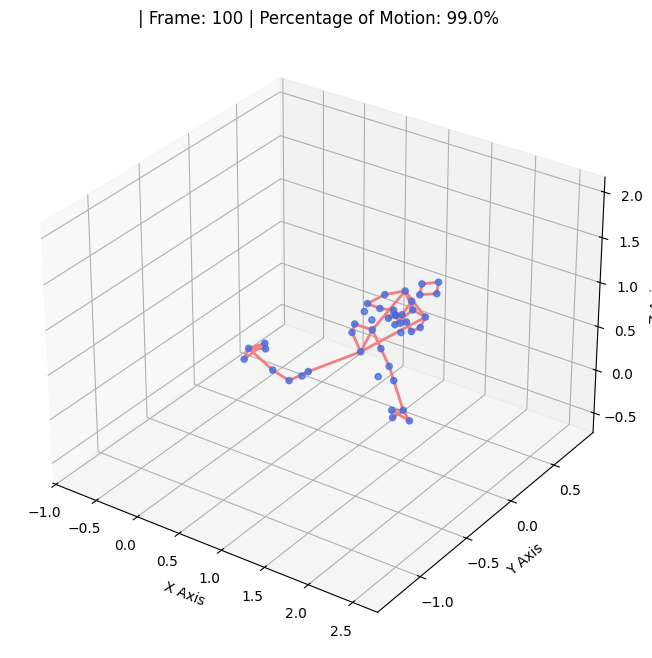

In [14]:
from animations import animate

# Saving plus 3 sigma pc1 animation
animate(final_df.to_pandas(), animation_type = 'theoretical', name = 'pc2-3')

In [18]:
# Run this in your Python environment to export PCA data
import numpy as np
import polars as pl
import json

# Load your normalized data and PCA results from pca.ipynb
norm = pl.read_parquet('./data/normalized_data.parquet')

# Create the wide-format feature matrix (same as in pca.ipynb)
df = norm.pivot(
    index=["userID", "sessionID", "pitchNum", "height", "weight", "pitchType", "pitchSpeed", "p_throws"],
    on=['markerID', 'frame_norm'],
    values=['x', 'y', 'z']
)

# Convert column names from Polars pivot format to standard format
import re
pattern = re.compile(r'([xyz])_\{\"([^\"]+)\",(\\d+)\}')
for col in df.columns:
    if col.startswith(('x_', 'y_', 'z_')):
        match = pattern.match(col)
        if match:
            axis, marker, frame = match.groups()
            new_col_name = f"{axis}_{marker}_{frame}"
            df = df.rename({col: new_col_name})

# Filter out rows with NaN values
df = df.filter(
    ~(
        pl.any_horizontal(
            pl.nth(range(8, len(df.columns))).is_null() | 
            pl.nth(range(8, len(df.columns))).is_nan()
        )
    )
)

# Extract features (everything after the metadata columns)
X = df.select(pl.nth(range(8, len(df.columns)))).to_numpy().T

# Compute PCA
X_mean = np.mean(X, axis=1, keepdims=True)
X_centered = X - X_mean

cov_mat = (X_centered.T @ X_centered) / (X_centered.shape[1] - 1)

eigenvalues, eigenvectors = np.linalg.eigh(cov_mat)

# Sort by eigenvalues in descending order
idx = eigenvalues.argsort()[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# Calculate variance explained
variance_explained = (eigenvalues / np.sum(eigenvalues)) * 100

# Take first 11 components
n_components = 11
eigenvalues_trunc = eigenvalues[:n_components]
eigenvectors_trunc = eigenvectors[:, :n_components]

# Prepare data for export
export_data = {
    "mean": X_mean.flatten().tolist(),
    "components": eigenvectors_trunc.T.tolist(),  # Shape: (n_components, n_features)
    "eigenvalues": eigenvalues_trunc.tolist(),
    "variance_explained": variance_explained[:n_components].tolist(),
    "marker_labels": [
    "LUPA", "RMELB", "RFHD", "LANK", "T10", "LMANK", "LMKNE", "RFIN", "C7",
    "RUPA", "LPSI", "RMKNE", "LWRA", "LSHO", "RWRA", "CLAV", "RPSI", "RSHO",
    "RMANK", "RANK", "LTOE", "RWRB", "LASI", "RELB", "RFRM", "LKNE", "RTHI",
    "RASI", "RBHD", "LFIN", "LTIB", "STRN", "LTHI", "LWRB", "RTOE", "RHEE",
    "LFRM", "RTIB", "LHEE", "LFHD", "LELB", "RKNE", "LBHD", "LMELB"],
    "n_features": X.shape[0],
    "n_samples": X.shape[1]
}

# Save to JSON
with open('pca_data.json', 'w') as f:
    json.dump(export_data, f)

print(f"✓ PCA data exported to pca_data.json")
print(f"  - Features: {export_data['n_features']}")
print(f"  - Samples: {export_data['n_samples']}")
print(f"  - Components: {n_components}")
print(f"  - Variance explained (PC1): {variance_explained[0]:.2f}%")
print(f"  - Cumulative variance (first 11): {variance_explained[:n_components].sum():.2f}%")

✓ PCA data exported to pca_data.json
  - Features: 13332
  - Samples: 410
  - Components: 11
  - Variance explained (PC1): 53.66%
  - Cumulative variance (first 11): 90.07%
